In [1]:
# Importing core libraries
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing Preprocessing Tools
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
# Importing Model Selection Utilities
from sklearn.model_selection import train_test_split, GridSearchCV

In [4]:
# Importing evaluation metrics
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

In [5]:
# Configuring General Settings
warnings.filterwarnings("ignore")
plt.style.use("default")
%matplotlib inline

# Loading the Dataset

In [6]:
#Importing the File
df = pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")

# Data Exploration

In [7]:
# first five records from dataframe
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [8]:
#Checking size of Dataframe
df.shape

(1200, 28)

In [9]:
#checking the column names
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [10]:
#checking for data types and missing values in the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

# Department-wise Performance Analysis

In [11]:
dept_df = df[["EmpDepartment", "PerformanceRating"]].copy()

In [12]:
# Calculating the Average Performance for each department
avg_performance = (dept_df.groupby("EmpDepartment")["PerformanceRating"].mean().sort_values(ascending=False))
print(avg_performance)

EmpDepartment
Development               3.085873
Data Science              3.050000
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Finance                   2.775510
Name: PerformanceRating, dtype: float64


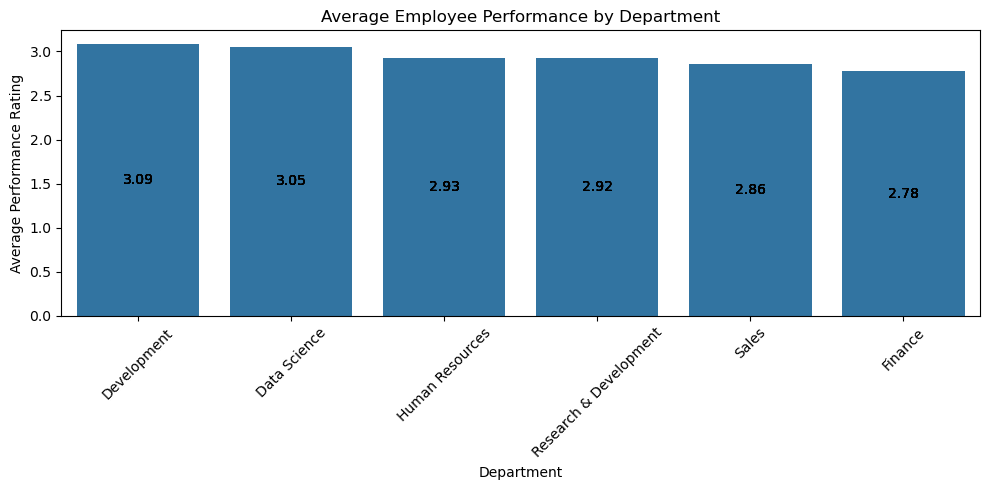

In [13]:
# Visualizing Average Department Performance
plt.figure(figsize=(10,5))
ax = sns.barplot(data=avg_performance.reset_index(),x="EmpDepartment",y="PerformanceRating")
for bar in ax.containers[0]:
    ax.bar_label(ax.containers[0],fmt="%.2f",label_type="center")
    
plt.title("Average Employee Performance by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# Counting employees under each performance rating
dept_summary = (dept_df.groupby(["EmpDepartment", "PerformanceRating"]).size().reset_index(name="EmployeeCount"))
print(dept_summary)

             EmpDepartment  PerformanceRating  EmployeeCount
0             Data Science                  2              1
1             Data Science                  3             17
2             Data Science                  4              2
3              Development                  2             13
4              Development                  3            304
5              Development                  4             44
6                  Finance                  2             15
7                  Finance                  3             30
8                  Finance                  4              4
9          Human Resources                  2             10
10         Human Resources                  3             38
11         Human Resources                  4              6
12  Research & Development                  2             68
13  Research & Development                  3            234
14  Research & Development                  4             41
15                   Sal

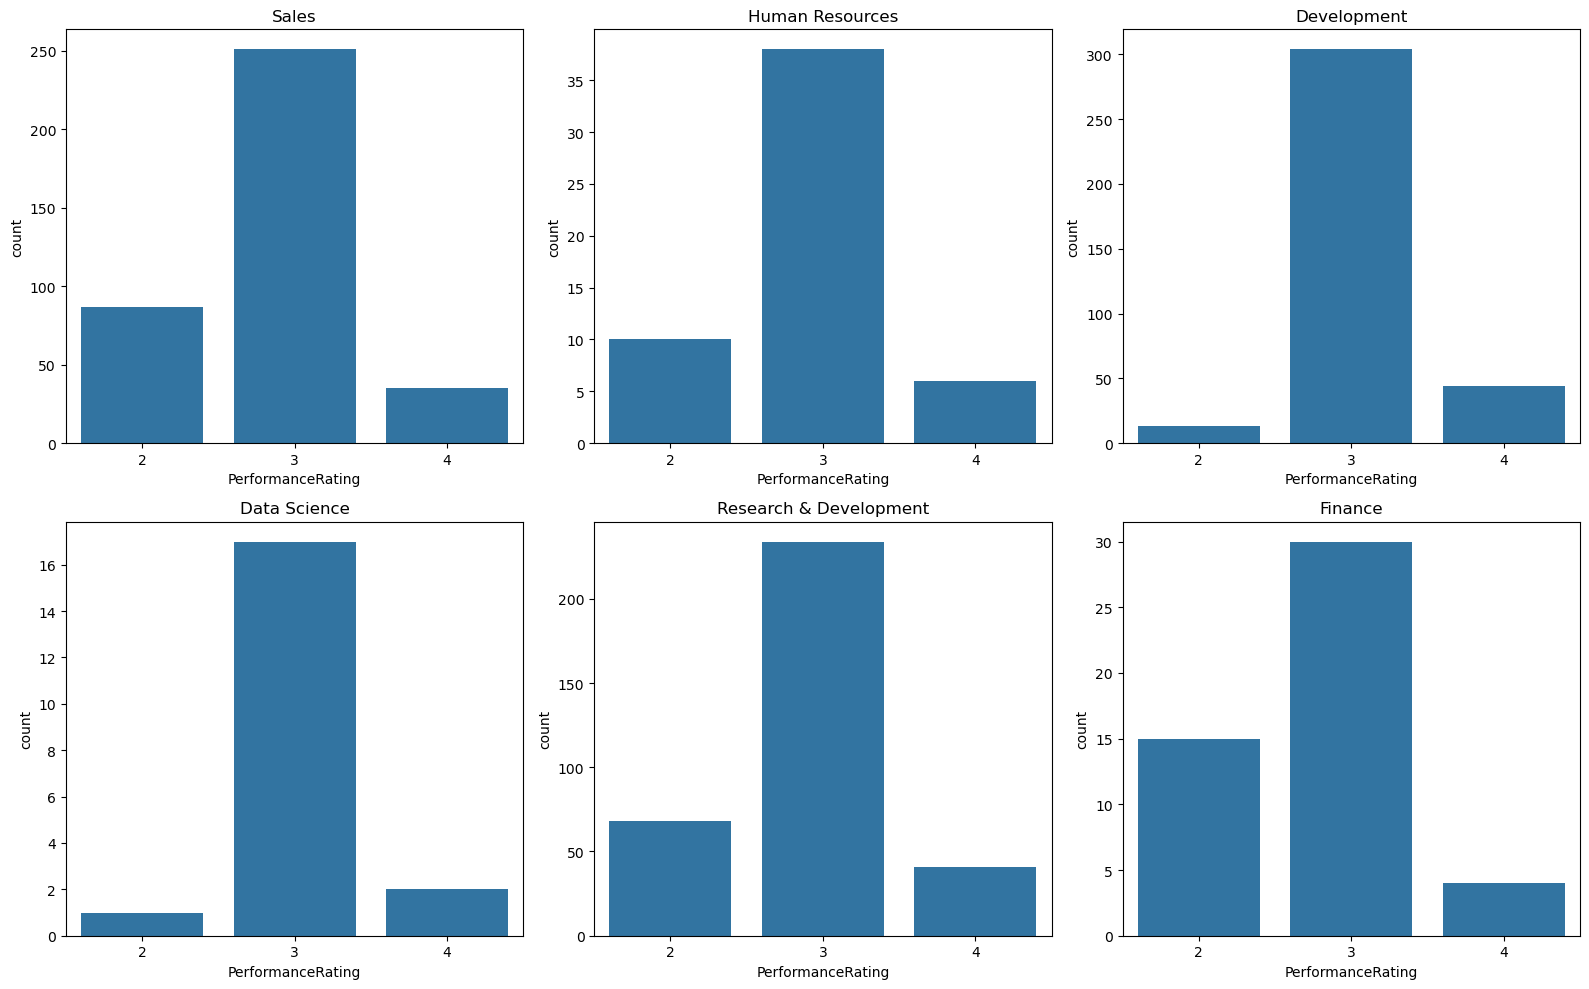

In [15]:
#visualizing all Departments
departments = dept_df["EmpDepartment"].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, dept in zip(axes, departments):
    temp = dept_df[dept_df["EmpDepartment"] == dept]
    sns.countplot(data=temp,x="PerformanceRating",ax=ax)
    ax.set_title(dept)

plt.tight_layout()
plt.show()

# Data Preprocessing

In [16]:
# Creating a copy of the dataset for model preparation
model_df = df.copy()

In [17]:
# Identifying categorical columns that needs encoding
categorical_features = ["EmpDepartment","EmpJobRole","BusinessTravelFrequency","EducationBackground","Gender","MaritalStatus","OverTime",]

In [18]:
# Converting categorical variables into numerical values for Models
encoder = LabelEncoder()

for feature in categorical_features:
    model_df[feature] = encoder.fit_transform(model_df[feature])

In [19]:
# Transformed df
model_df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,1,2,2,5,13,2,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,1,2,2,5,13,2,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,1,1,1,5,13,1,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,1,0,0,3,8,2,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,1,2,2,5,13,2,16,4,...,4,10,1,3,2,2,2,2,No,3


# Feature Selection

In [20]:
#Removing unneccessary Columns
model_df.drop("EmpNumber",axis=1,inplace=True)
model_df.drop("Attrition",axis=1,inplace=True)

In [21]:
# Generating correlation matrix
correlation_matrix = model_df.corr()
correlation_matrix["PerformanceRating"].sort_values(ascending=False)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
OverTime                        0.050206
MaritalStatus                   0.024172
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EducationBackground             0.005607
EmpJobSatisfaction              0.000606
Gender                         -0.001780
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
BusinessTravelFrequency        -0.031025
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
EmpJobRole                     -0.096209
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
EmpDepartment   

In [22]:
# Choosing Predictor Variables
selected_features = [
    "EmpEnvironmentSatisfaction",
    "EmpLastSalaryHikePercent",
    "EmpWorkLifeBalance",
    "EmpJobRole",
    "ExperienceYearsAtThisCompany",
    "YearsWithCurrManager",
    "ExperienceYearsInCurrentRole",
    "EmpDepartment",
    "YearsSinceLastPromotion"]

In [23]:
X = model_df[selected_features]
y = model_df["PerformanceRating"]

# Splitting Training and Testing Data

In [24]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42, stratify=y)

In [25]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled.shape

(840, 9)

In [27]:
X_test_scaled.shape

(360, 9)

# Models
#### Algorithms such as Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest, Support Vector Machine, Naive Bayes, Artificial Neural Network and XGBoost are used to calculate the accuracy

In [28]:
#Creating a function to evaluate models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test):
    # Generate predictions on the test dataset
    predictions = model.predict(X_test)

    # Display model accuracy
    print(f"Accuracy Score: {accuracy_score(y_test, predictions):.3f}")

    # Display Precision, Recall and F1-score
    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    # Display Confusion Matrix
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, predictions))

### 1. Logistic Regression

In [29]:
# Importing Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression

In [30]:
# Creating the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

In [31]:
# To Train the model using training data
logistic_model.fit(X_train_scaled,y_train)


# Evaluating model performance
print("========== Logistic Regression ==========")

evaluate_model(logistic_model,X_test_scaled,y_test)

========== Logistic Regression ==========
Accuracy Score: 0.825

Classification Report
              precision    recall  f1-score   support

           2       0.60      0.45      0.51        58
           3       0.85      0.94      0.89       262
           4       0.89      0.62      0.74        40

    accuracy                           0.82       360
   macro avg       0.78      0.67      0.71       360
weighted avg       0.82      0.82      0.81       360


Confusion Matrix
[[ 26  31   1]
 [ 14 246   2]
 [  3  12  25]]


### 2. K-Nearest Neighbor (KNN)

In [32]:
# Importing KNN classifier
from sklearn.neighbors import KNeighborsClassifier

In [33]:
# Creating KNN model
knn_model = KNeighborsClassifier(n_neighbors=7,metric="euclidean")

In [34]:
# Training the model
knn_model.fit(X_train_scaled,y_train)

# Evaluate performance
print("========== K-Nearest Neighbor ==========")

evaluate_model(knn_model,X_test_scaled,y_test)

========== K-Nearest Neighbor ==========
Accuracy Score: 0.819

Classification Report
              precision    recall  f1-score   support

           2       0.67      0.55      0.60        58
           3       0.85      0.93      0.89       262
           4       0.79      0.47      0.59        40

    accuracy                           0.82       360
   macro avg       0.77      0.65      0.69       360
weighted avg       0.81      0.82      0.81       360


Confusion Matrix
[[ 32  26   0]
 [ 13 244   5]
 [  3  18  19]]


### 3. Decision Tree with GridSearchCV

In [35]:
# Importing required libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [36]:
# Creating Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

In [37]:
# Define parameters to test
tree_parameters = {"criterion": ["gini","entropy"],"min_samples_split": [2,4,6]}

In [38]:
# Perform Grid Search
decision_tree_grid = GridSearchCV(estimator=decision_tree,param_grid=tree_parameters,cv=5,scoring="accuracy")

In [39]:
# Train model
decision_tree_grid.fit(X_train,y_train)

# Display best parameters
print("Best Parameters:")
print(decision_tree_grid.best_params_)


# Evaluate model
print("========== Decision Tree ==========")

evaluate_model(decision_tree_grid,X_test,y_test)

Best Parameters:
{'criterion': 'entropy', 'min_samples_split': 6}
========== Decision Tree ==========
Accuracy Score: 0.900

Classification Report
              precision    recall  f1-score   support

           2       0.75      0.83      0.79        58
           3       0.94      0.93      0.93       262
           4       0.89      0.82      0.86        40

    accuracy                           0.90       360
   macro avg       0.86      0.86      0.86       360
weighted avg       0.90      0.90      0.90       360


Confusion Matrix
[[ 48  10   0]
 [ 15 243   4]
 [  1   6  33]]


### 4. Random Forest with GridSearchCV

In [40]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [41]:
# Create Random Forest model
random_forest = RandomForestClassifier(random_state=42,n_estimators=100)

In [42]:
# Define hyperparameters
rf_parameters = {"criterion": ["gini","entropy"],"min_samples_split": [2,4],"min_samples_leaf": [1,2]}

In [43]:
# Apply GridSearchCV
random_forest_grid = GridSearchCV(estimator=random_forest,param_grid=rf_parameters,cv=5,scoring="accuracy")

In [44]:
# Train model
random_forest_grid.fit(X_train,y_train)

# Display best parameters
print("Best Parameters:")
print(random_forest_grid.best_params_)


# Evaluate model
print("========== Random Forest ==========")

evaluate_model(random_forest_grid,X_test,y_test)

Best Parameters:
{'criterion': 'entropy', 'min_samples_leaf': 2, 'min_samples_split': 2}
========== Random Forest ==========
Accuracy Score: 0.944

Classification Report
              precision    recall  f1-score   support

           2       0.89      0.88      0.89        58
           3       0.95      0.98      0.96       262
           4       1.00      0.82      0.90        40

    accuracy                           0.94       360
   macro avg       0.95      0.89      0.92       360
weighted avg       0.95      0.94      0.94       360


Confusion Matrix
[[ 51   7   0]
 [  6 256   0]
 [  0   7  33]]


### 5. Support Vector Machine (SVM)

In [45]:
# Import Support Vector Classifier
from sklearn.svm import SVC

In [46]:
# Create SVM model using RBF kernel
svm_model = SVC(kernel="rbf",C=10,random_state=42)

In [47]:
# Train the model
svm_model.fit(X_train_scaled,y_train)

# Evaluate model performance
print("========== Support Vector Machine ==========")

evaluate_model(svm_model,X_test_scaled,y_test)

========== Support Vector Machine ==========
Accuracy Score: 0.864

Classification Report
              precision    recall  f1-score   support

           2       0.78      0.69      0.73        58
           3       0.89      0.95      0.92       262
           4       0.79      0.55      0.65        40

    accuracy                           0.86       360
   macro avg       0.82      0.73      0.77       360
weighted avg       0.86      0.86      0.86       360


Confusion Matrix
[[ 40  16   2]
 [  9 249   4]
 [  2  16  22]]


### 6. Gaussian Naive Bayes

In [48]:
# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

In [49]:
# Create model
nb_model = GaussianNB()

In [50]:
# Train the model
nb_model.fit(X_train_scaled,y_train)

# Evaluate model
print("========== Gaussian Naive Bayes ==========")

evaluate_model(nb_model,X_test_scaled,y_test)

========== Gaussian Naive Bayes ==========
Accuracy Score: 0.825

Classification Report
              precision    recall  f1-score   support

           2       0.61      0.48      0.54        58
           3       0.86      0.92      0.89       262
           4       0.84      0.68      0.75        40

    accuracy                           0.82       360
   macro avg       0.77      0.69      0.73       360
weighted avg       0.82      0.82      0.82       360


Confusion Matrix
[[ 28  30   0]
 [ 15 242   5]
 [  3  10  27]]


### 7. Artificial Neural Network (ANN)

In [51]:
# Import Neural Network classifier
from sklearn.neural_network import MLPClassifier

In [52]:
# Create ANN model
ann_model = MLPClassifier(hidden_layer_sizes=(64,32),max_iter=1000,random_state=42)

In [53]:
# Train model
ann_model.fit(X_train_scaled,y_train)

# Evaluate model
print("========== Artificial Neural Network ==========")

evaluate_model(ann_model,X_test_scaled,y_test)

========== Artificial Neural Network ==========
Accuracy Score: 0.856

Classification Report
              precision    recall  f1-score   support

           2       0.75      0.67      0.71        58
           3       0.89      0.93      0.91       262
           4       0.74      0.65      0.69        40

    accuracy                           0.86       360
   macro avg       0.79      0.75      0.77       360
weighted avg       0.85      0.86      0.85       360


Confusion Matrix
[[ 39  17   2]
 [ 12 243   7]
 [  1  13  26]]


### 8. XGBoost Classifier

In [54]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
target_encoder = LabelEncoder()

# Convert performance ratings into 0-based classes
y_train_xgb = target_encoder.fit_transform(y_train)

y_test_xgb = target_encoder.transform(y_test)

In [55]:
# Import XGBoost classifier
from xgboost import XGBClassifier

In [56]:
# Create XGBoost model
xgb_model = XGBClassifier(random_state=42,eval_metric="mlogloss")

In [57]:
# Train model
xgb_model.fit(X_train,y_train_xgb)

# Evaluate model
print("========== XGBoost ==========")

evaluate_model(xgb_model,X_test,y_test_xgb)

========== XGBoost ==========
Accuracy Score: 0.914

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.83      0.83        58
           1       0.94      0.94      0.94       262
           2       0.85      0.85      0.85        40

    accuracy                           0.91       360
   macro avg       0.88      0.87      0.88       360
weighted avg       0.91      0.91      0.91       360


Confusion Matrix
[[ 48  10   0]
 [  9 247   6]
 [  0   6  34]]


In [58]:
# Comparing Model Performance
from sklearn.metrics import accuracy_score
model_results = {"Logistic Regression":accuracy_score(y_test,logistic_model.predict(X_test_scaled)),
"KNN":accuracy_score(y_test,knn_model.predict(X_test_scaled)),
"Decision Tree":accuracy_score(y_test,decision_tree_grid.predict(X_test)),
"Random Forest":accuracy_score(y_test,random_forest_grid.predict(X_test)),
"SVM":accuracy_score(y_test,svm_model.predict(X_test_scaled)),
"Naive Bayes":accuracy_score(y_test,nb_model.predict(X_test_scaled)),
"ANN":accuracy_score(y_test,ann_model.predict(X_test_scaled)),
"XGBoost":accuracy_score(y_test_xgb,xgb_model.predict(X_test))}

In [59]:
# Convert results into dataframe
results_df = pd.DataFrame(model_results.items(),columns=["Model", "Accuracy"])


# Sort models by accuracy
results_df = results_df.sort_values(by="Accuracy",ascending=False)


results_df

,Model,Accuracy
3,Random Forest,0.944444
7,XGBoost,0.913889
2,Decision Tree,0.900000
4,SVM,0.863889
6,ANN,0.855556
0,Logistic Regression,0.825000
5,Naive Bayes,0.825000
1,KNN,0.819444


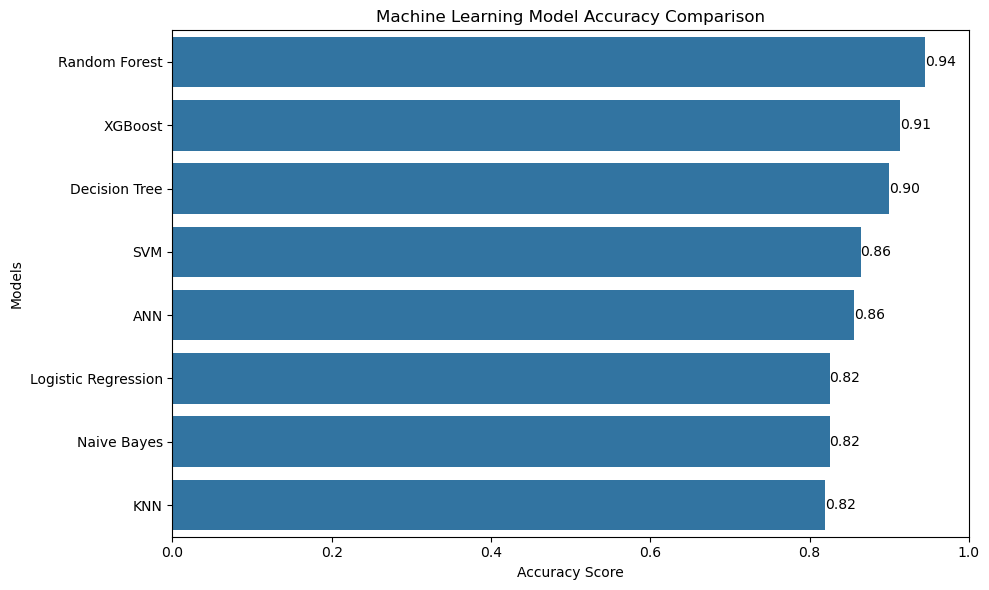

In [60]:
# Visualizing Model Accuracy Comparison

plt.figure(figsize=(10,6))

ax = sns.barplot(data=results_df,x="Accuracy",y="Model")

# Display accuracy value on each bar
for container in ax.containers:ax.bar_label(container,fmt="%.2f")

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Accuracy Score")
plt.ylabel("Models")

plt.xlim(0,1)

plt.tight_layout()
plt.show()

In [61]:
# Choosing the Best Model
best_model = results_df.iloc[0]

print("Best Performing Model:")
print(best_model["Model"])

print("\nAccuracy:")
print(round(best_model["Accuracy"],3))

Best Performing Model:
Random Forest

Accuracy:
0.944


In [62]:
# Random Forest Feature Importance Analysis
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance":random_forest_grid.best_estimator_.feature_importances_})

# Sorting features by importance
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print("\nFeature Importance Ranking")

print(feature_importance)


Feature Importance Ranking
                        Feature  Importance
1      EmpLastSalaryHikePercent    0.275874
0    EmpEnvironmentSatisfaction    0.256811
8       YearsSinceLastPromotion    0.144085
2            EmpWorkLifeBalance    0.069748
3                    EmpJobRole    0.060770
6  ExperienceYearsInCurrentRole    0.057595
7                 EmpDepartment    0.046654
4  ExperienceYearsAtThisCompany    0.046211
5          YearsWithCurrManager    0.042252


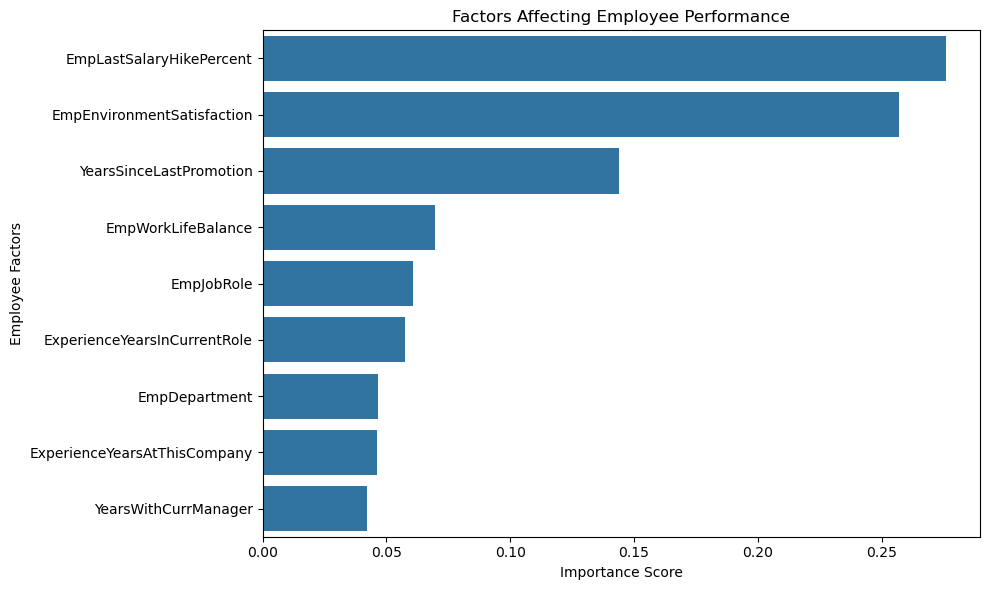

In [63]:
# Visualizing Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(data=feature_importance,x="Importance",y="Feature")

plt.title("Factors Affecting Employee Performance")
plt.xlabel("Importance Score")
plt.ylabel("Employee Factors")

plt.tight_layout()
plt.show()

In [64]:
# Top 3 Important Factors
print("\nTop 3 Factors Affecting Employee Performance:")
print(feature_importance.head(3))


Top 3 Factors Affecting Employee Performance:
                      Feature  Importance
1    EmpLastSalaryHikePercent    0.275874
0  EmpEnvironmentSatisfaction    0.256811
8     YearsSinceLastPromotion    0.144085


In [65]:
import joblib

model_file = "INX_Future_Inc.pkl"

joblib.dump(random_forest_grid, model_file)

print("Model saved successfully!")

Model saved successfully!
